# SLX Contra Simple Ridge Regression

Upon investigating model performance with train/validate splits for the 2019 and 2025 snapshots, factor analysis was observed to outperform principal component analysis. Simple ridge regression models specifically performed well. Since slx was only tried on pca with 20 components previously, this new insight warrants returning to slx for comparison on respective reduction techniques.

In [171]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import pairwise_distances
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold

import json
from itertools import product

from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score
import geopandas as gpd
from shapely.geometry import shape


from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.linear_model import Ridge, Lasso, ElasticNet

from scipy.stats import spearmanr, pearsonr


RANDOM_STATE = 19

## Setup Features and Target

In [105]:
# Load dataset and imd to create merged dataset with target variable

indicators_2019 = pd.read_parquet('combined_indicators_2019.parquet', engine='fastparquet')
indicators_2025 = pd.read_parquet('combined_indicators_2025.parquet', engine='fastparquet')

scores_2019 = pd.read_csv('imd_2019_scores.csv')
scores_2025 = pd.read_csv('imd_2025_scores.csv')

lsoa_lookup = pd.read_csv('lsoa_2011_2021_lookup.csv')

### Perform Joins

In [106]:
scores_2019.rename(columns={'LSOA code (2011)': 'lsoa_code_11',
                           'Index of Multiple Deprivation (IMD) Score': 'imd_score'
                          }, inplace=True)

# lsoa codes were changed in 2021, so 2019 codes are converted to 2021 codes using the lookup table
scores_2019 = scores_2019.merge(lsoa_lookup[['lsoa_code_11', 'lsoa_code_21']], on='lsoa_code_11', how='right')
scores_2019.drop(columns=['lsoa_code_11'], inplace=True)
scores_2019.rename(columns={'lsoa_code_21': 'lsoa_code'}, inplace=True)


scores_2025.rename(columns={'LSOA code (2021)': 'lsoa_code',
                           'Index of Multiple Deprivation (IMD) Score': 'imd_score'
                          }, inplace=True)

scores_2019 = scores_2019[['lsoa_code', 'imd_score']]
scores_2025 = scores_2025[['lsoa_code', 'imd_score']]

# Merge features and target datasets on 'lsoa_code'
data_2019 = pd.merge(indicators_2019, scores_2019, on='lsoa_code')
data_2025 = pd.merge(indicators_2025, scores_2025, on='lsoa_code', how='left')

In [107]:
# Ensure features are consistent between datasets
common_features = list(set(data_2019.columns).intersection(set(data_2025.columns)))
data_2019 = data_2019[common_features]
data_2025 = data_2025[common_features]

In [108]:
# Check that now datasets have the same shape
data_2019.shape == data_2025.shape   

True

### NaN, Null and Inf Values

In [109]:
if np.isinf(data_2019.select_dtypes(include=['number'])).sum().sum()>0:
    print("Warning: Infinite values found in 2019 dataset, replaced with NaN.")
    data_2019.replace([np.inf, -np.inf], np.nan, inplace=True) 

if np.isinf(data_2025.select_dtypes(include=['number'])).sum().sum()>0:
    print("Warning: Infinite values found in 2025 dataset.")
    data_2025.replace([np.inf, -np.inf], np.nan, inplace=True)

In [110]:
# 2019

missingness = data_2019.isna().sum().sort_values(ascending=False)
missingness_percent = (missingness / len(data_2019)) * 100
missingness_df_2019 = pd.DataFrame({
    'feature': missingness.index,
    'missing_count': missingness.values,
    'missing_percent': missingness_percent.values
})

data_2019 = data_2019.drop(columns=missingness_df_2019[missingness_df_2019['missing_percent'] > 20]['feature'])
data_2019 = data_2019.fillna(data_2019.median(numeric_only=True)) 

missingness_df_2019.sort_values('missing_percent', ascending=False).head(10)

,feature,missing_count,missing_percent
0,resolution_rate,268,100.000000
1,ratio_fast_food_takeaway_to_food_dining_500,36,13.432836
2,ratio_sustainable_transport_to_transport_car_1000,27,10.074627
3,ratio_fast_food_takeaway_to_healthcare_access_...,22,8.208955
4,ratio_alcohol_gambling_to_financial_services_500,22,8.208955
5,Formal action is not in the public interest,9,3.358209
6,burglary,9,3.358209
7,other-theft,9,3.358209
8,shoplifting,9,3.358209
9,vehicle-crime,9,3.358209


In [111]:
# 2025

missingness = data_2025.isna().sum().sort_values(ascending=False)
missingness_percent = (missingness / len(data_2025)) * 100
missingness_2025_df = pd.DataFrame({
    'feature': missingness.index,
    'missing_count': missingness.values,
    'missing_percent': missingness_percent.values
})

data_2025 = data_2025.drop(columns=missingness_2025_df[missingness_2025_df['missing_percent'] > 20]['feature'])
data_2025 = data_2025.fillna(data_2025.median(numeric_only=True)) 

missingness_2025_df.sort_values('missing_percent', ascending=False).head(10)

,feature,missing_count,missing_percent
0,count_professional_services_2000,0,0.0
1,ratio_alcohol_gambling_to_financial_services_2000,0,0.0
2,count_professional_services_1000,0,0.0
3,possession-of-weapons,0,0.0
4,count_alcohol_gambling_5000,0,0.0
5,count_education_skills_1500,0,0.0
6,count_transport_car_2500,0,0.0
7,count_healthcare_access_500,0,0.0
8,count_elderly_care_1500,0,0.0
9,F_mean_price,0,0.0


In [112]:
# Ensure datasets still have the same shape after dropping features with high missingness
consistent_shape = data_2019.shape == data_2025.shape

print(f"Datasets have consistent shapes: {consistent_shape}")

if not consistent_shape:
    # redo the common features step to ensure both datasets have the same features after dropping those with high missingness
    common_features = list(set(data_2019.columns).intersection(set(data_2025.columns)))
    data_2019 = data_2019[common_features]
    data_2025 = data_2025[common_features]


Datasets have consistent shapes: False


### Define Features and Targets

In [113]:
data_2019.set_index("lsoa_code", inplace=True)
data_2025.set_index("lsoa_code", inplace=True)

X_2019 = data_2019.drop(columns=['imd_score']).values
y_2019 = data_2019['imd_score'].values

X_2025 = data_2025.drop(columns=['imd_score']).values
y_2025 = data_2025['imd_score'].values

## Setup GeoSpatial Aspects

### Load Geo Shapes

In [114]:
lsoa_shapes = pd.read_csv("geography_lookup.csv")

# convert geojson string to geometry
lsoa_shapes["geometry"] = lsoa_shapes["geo_shape"].apply(lambda x: shape(json.loads(x)))
lsoa_shapes = lsoa_shapes[["lsoa_code", "geometry"]]

print(lsoa_shapes.head())

# merge modelling data to get full geo-spatial dataset
gdf = gpd.GeoDataFrame(lsoa_shapes, geometry="geometry", crs="EPSG:4326").merge(data_2025, on="lsoa_code", how="left")


   lsoa_code                                           geometry
0  E01014488  MULTIPOLYGON (((-2.581270401359658 51.47053350...
1  E01014693  MULTIPOLYGON (((-2.581328182358106 51.51617262...
2  E01033909  MULTIPOLYGON (((-2.598659490202402 51.45494441...
3  E01033903  MULTIPOLYGON (((-2.584357699648935 51.45285959...
4  E01032514  MULTIPOLYGON (((-2.59432877773493 51.409612444...


### Get Distance Matrix

In [115]:
# Get centroid coordinates for distance matrix
coords = np.array(list(zip(gdf.geometry.centroid.x, gdf.geometry.centroid.y)))

# Compute distance matrix
distances = pairwise_distances(coords)

# Create adjacency: neighbors if within some distance threshold
threshold = 0.01  # roughly 700 meters with 1 ~ 111km
w = (distances < threshold).astype(float)

# row-standardize weights
w = w / w.sum(axis=1, keepdims=True)

C:\Users\danie\AppData\Local\Temp\ipykernel_296\3925287771.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  coords = np.array(list(zip(gdf.geometry.centroid.x, gdf.geometry.centroid.y)))


### Get Spatial CV Clusters

In [116]:
# Setup for spatial cross validation 

centroids = np.array(list(zip(gdf.geometry.centroid.x, gdf.geometry.centroid.y)))
n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE).fit(centroids)
gdf["cluster_id"] = kmeans.labels_

groups = gdf["cluster_id"].values

C:\Users\danie\AppData\Local\Temp\ipykernel_296\2544173036.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = np.array(list(zip(gdf.geometry.centroid.x, gdf.geometry.centroid.y)))
c:\Users\danie\.venvs\ds\Lib\site-packages\geopandas\geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)


## Modelling

## Define Spatial CV, Reductions and Eval Params

In [117]:
initial_feature_sets = {
    'pca_100': 100,
    'pca_75' : 75,
    'pca_50': 50,
    'pca_20': 20, 
    'pca_10': 10,
    'fa_100': 100,
    'fa_75' : 75,
    'fa_50': 50,
    'fa_20': 20, 
    'fa_10': 10,
    'scaled': None,
    'none': None,
}

ridge_params = [0.1, 1.0, 10.0, 20.0, 50.0, 80.0, 100.0] # chosen using knowledge from 19/25 experiments  
lasso_params = [0.001, 0.01, 0.1, 1] # chosen as base


gkf = GroupKFold(n_splits=5)

## Perform CV

### Train and Validate Between Snapshots

In [196]:
def evaluate_models(
        feature_sets: dict = {'scaled': None},
        alphas: list = [0.01, 0.1, 1, 10, 100],
        elnet_ratio: list = [0.2, 0.5, 0.8],
        models: list = ['Ridge', 'SLX'],
        feature_names: list | None = None
):

    results_row = []
    coefs_list = []

    for direction in ['2019 -> 2025', '2025 -> 2019']:

        if direction == '2019 -> 2025':
            X_cv = X_2019
            y_cv = y_2019
            X_val = X_2025
            y_val = y_2025
        else:
            X_cv = X_2025
            y_cv = y_2025
            X_val = X_2019
            y_val = y_2019       

        for reduction_config in feature_sets.keys():
            n = feature_sets[reduction_config]

            for model_type in models:
                if model_type not in ['Ridge', 'SLX', 'Lasso', 'ElasticNet']:
                    continue

                if model_type != 'ElasticNet':
                    elnet_ratio = [0]

                for a, lr_ratio  in product(alphas, elnet_ratio):

                    r2_scores = []
                    rmse_scores = []
                    spearmensr_scores = []
                    coeffs_cv = []

                    # CV loop
                    for train_idx, test_idx in gkf.split(X_cv, y_cv, groups=groups):

                        # Train/test split
                        X_train_raw, X_test_raw = X_cv[train_idx], X_cv[test_idx]
                        y_train, y_test = y_cv[train_idx], y_cv[test_idx]

                        scaler = StandardScaler()
                        X_train_scaled = scaler.fit_transform(X_train_raw)
                        X_test_scaled = scaler.transform(X_test_raw)

                        # Dimension reduction
                        if 'pca' in reduction_config:
                            pca = PCA(n_components=n)
                            X_train = pca.fit_transform(X_train_scaled)
                            X_test = pca.transform(X_test_scaled)
                            # Name features as PCA1, PCA2, ...
                            feature_names_curr = [f"PCA_{i+1}" for i in range(n)]
                        elif 'fa' in reduction_config:
                            fa = FactorAnalysis(n_components=n)
                            X_train = fa.fit_transform(X_train_scaled)
                            X_test = fa.transform(X_test_scaled)
                            feature_names_curr = [f"FA_{i+1}" for i in range(n)]
                        elif 'scaled' in reduction_config:
                            X_train = X_train_scaled
                            X_test = X_test_scaled
                            feature_names_curr = feature_names if feature_names is not None else [f"X{i}" for i in range(X_train.shape[1])]
                        else:
                            X_train = X_train_raw
                            X_test = X_test_raw
                            feature_names_curr = feature_names if feature_names is not None else [f"X{i}" for i in range(X_train.shape[1])]

                        # Spatial features
                        WX_train = w[np.ix_(train_idx, train_idx)] @ X_train
                        WX_test  = w[np.ix_(test_idx, train_idx)]  @ X_train
                        X_train_slx = np.hstack([X_train, WX_train])
                        X_test_slx = np.hstack([X_test, WX_test])
                        if model_type == 'SLX':
                            feature_names_curr = feature_names_curr + [f"W_{name}" for name in feature_names_curr]

                        # Model selection
                        if model_type == 'Ridge':
                            model = Ridge(alpha=a)
                            X_tr, X_te = X_train, X_test
                        elif model_type == 'Lasso':
                            model = Lasso(alpha=a, max_iter=10000, random_state=RANDOM_STATE)
                            X_tr, X_te = X_train, X_test
                        elif model_type == 'SLX':
                            model = Ridge(alpha=a)
                            X_tr, X_te = X_train_slx, X_test_slx
                        elif model_type == 'ElasticNet':
                            model = ElasticNet(alpha=a, l1_ratio=lr_ratio, max_iter=10000, random_state=RANDOM_STATE)
                            X_tr, X_te = X_train, X_test

                        # Fit and predict
                        model.fit(X_tr, y_train)
                        y_pred = model.predict(X_te)

                        r2_scores.append(r2_score(y_test, y_pred))
                        rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))
                        spearmens_score, _ = spearmanr(y_test, y_pred)
                        spearmensr_scores.append(spearmens_score)
                        coeffs_cv.append(model.coef_)

                    # Validation model
                    scaler = StandardScaler()
                    X_cv_scaled = scaler.fit_transform(X_cv)
                    X_val_scaled = scaler.transform(X_val)

                    if 'pca' in reduction_config:
                        pca = PCA(n_components=n)
                        X_cv_red = pca.fit_transform(X_cv_scaled)
                        X_val_red = pca.transform(X_val_scaled)
                    elif 'fa' in reduction_config:
                        fa = FactorAnalysis(n_components=n)
                        X_cv_red = fa.fit_transform(X_cv_scaled)
                        X_val_red = fa.transform(X_val_scaled)
                    else:
                        X_cv_red = X_cv_scaled
                        X_val_red = X_val_scaled

                    if model_type == 'SLX':
                        WX_cv = w @ X_cv_red
                        X_cv_red = np.hstack([X_cv_red, WX_cv])
                        WX_val = w @ X_val_red
                        X_val_red = np.hstack([X_val_red, WX_val])

                    # Fit validation model
                    val_model = None
                    if model_type == 'Ridge':
                        val_model = Ridge(alpha=a)
                    elif model_type == 'Lasso':
                        val_model = Lasso(alpha=a, max_iter=10000, random_state=RANDOM_STATE)
                    elif model_type == 'ElasticNet':
                        val_model = ElasticNet(alpha=a, l1_ratio=lr_ratio, max_iter=10000, random_state=RANDOM_STATE)
                    elif model_type == 'SLX':
                        val_model = Ridge(alpha=a)

                    val_model.fit(X_cv_red, y_cv)
                    val_coef = val_model.coef_

                    # Store results
                    results_row.append(
                        {
                            'feature_set': reduction_config,
                            'model': model_type,
                            'cv_rmse_std': np.std(rmse_scores),
                            'cv_rmse_mean': np.mean(rmse_scores),
                            'cv_r2_std': np.std(r2_scores),
                            'cv_r2_mean': np.mean(r2_scores),
                            'cv_spearmensr_std':np.std(spearmensr_scores),
                            'cv_spearmensr_mean': np.mean(spearmensr_scores),
                            'val_r2': r2_score(y_val, val_model.predict(X_val_red)), 
                            'spearmensr': spearmanr(y_val, val_model.predict(X_val_red))[0], 
                            'alpha': a,
                            'direction': direction,
                        }
                    )

                    # Build coefficient DataFrame rows with feature names
                    coeffs_cv_arr = np.array(coeffs_cv)
                    for idx, fname in enumerate(feature_names_curr):
                        coefs_list.append({
                            'feature_name': fname,
                            'validation_value': val_coef[idx],
                            'cv_mean': coeffs_cv_arr[:, idx].mean(),
                            'cv_spread': coeffs_cv_arr[:, idx].std(),
                            'model': model_type,
                            'alpha': a,
                            'feature_set': reduction_config,
                            'direction': direction
                        })

    # Return both
    results_df = pd.DataFrame(results_row)
    coefs_df = pd.DataFrame(coefs_list).set_index('feature_name')
    return results_df, coefs_df

In [197]:
retusults_df, coefs_df = evaluate_models()

In [130]:
results_df = evaluate_models(
    feature_sets=initial_feature_sets,
    lasso_alphas=lasso_params,
    ridge_alphas=ridge_params
)

c:\Users\danie\.venvs\ds\Lib\site-packages\sklearn\decomposition\_factor_analysis.py:286: RuntimeWarning: divide by zero encountered in log
  ll = llconst + np.sum(np.log(s))
c:\Users\danie\.venvs\ds\Lib\site-packages\sklearn\decomposition\_factor_analysis.py:290: RuntimeWarning: invalid value encountered in scalar subtract
  if (ll - old_ll) < self.tol:
c:\Users\danie\.venvs\ds\Lib\site-packages\sklearn\decomposition\_factor_analysis.py:296: ConvergenceWarning: FactorAnalysis did not converge. You might want to increase the number of iterations.
  warnings.warn(
c:\Users\danie\.venvs\ds\Lib\site-packages\sklearn\decomposition\_factor_analysis.py:286: RuntimeWarning: divide by zero encountered in log
  ll = llconst + np.sum(np.log(s))
c:\Users\danie\.venvs\ds\Lib\site-packages\sklearn\decomposition\_factor_analysis.py:290: RuntimeWarning: invalid value encountered in scalar subtract
  if (ll - old_ll) < self.tol:
c:\Users\danie\.venvs\ds\Lib\site-packages\sklearn\decomposition\_factor_

KeyboardInterrupt: 

## Evaluate

In [176]:
results_df.sort_values(by='spearmensr', ascending=False).head(10)

,feature_set,model,cv_rmse_std,cv_rmse_mean,cv_r2_std,cv_r2_mean,cv_spearmensr_std,cv_spearmensr_mean,val_r2,spearmensr,alpha,direction
3,scaled,Ridge,1.367948,6.377352,0.065152,0.839660,0.014980,0.931915,-0.120963,0.920434,100.0,2019 -> 2025
2,scaled,Ridge,1.654176,6.422520,0.086032,0.834270,0.015503,0.926938,-0.303108,0.909769,10.0,2019 -> 2025
1,scaled,Ridge,0.964970,8.021036,0.054731,0.750811,0.007371,0.890245,-0.912353,0.873604,1.0,2019 -> 2025
6,scaled,SLX,0.990297,9.214338,0.075686,0.668211,0.040490,0.838968,-3.973255,0.869701,10.0,2019 -> 2025
5,scaled,SLX,1.505571,9.148180,0.099332,0.674365,0.042880,0.829096,-1.756363,0.867855,1.0,2019 -> 2025
7,scaled,SLX,1.742097,8.590498,0.104509,0.708883,0.052142,0.863035,-5.210214,0.843887,100.0,2019 -> 2025
4,scaled,SLX,1.404504,8.188384,0.085699,0.738248,0.016022,0.865319,-0.534343,0.837111,0.1,2019 -> 2025
0,scaled,Ridge,0.677640,10.078712,0.055642,0.607375,0.042960,0.834114,-1.977462,0.768562,0.1,2019 -> 2025
11,scaled,Ridge,1.180899,6.145310,0.053070,0.844295,0.018321,0.932558,-2.739210,0.293645,100.0,2025 -> 2019
9,scaled,Ridge,1.182625,7.017528,0.057945,0.798230,0.062149,0.866037,-124.414356,0.117050,1.0,2025 -> 2019


In [177]:
results_df.sort_values(by='cv_r2_mean', ascending=False).head(10)

,feature_set,model,cv_rmse_std,cv_rmse_mean,cv_r2_std,cv_r2_mean,cv_spearmensr_std,cv_spearmensr_mean,val_r2,spearmensr,alpha,direction
11,scaled,Ridge,1.180899,6.145310,0.053070,0.844295,0.018321,0.932558,-2.739210,0.293645,100.0,2025 -> 2019
3,scaled,Ridge,1.367948,6.377352,0.065152,0.839660,0.014980,0.931915,-0.120963,0.920434,100.0,2019 -> 2025
2,scaled,Ridge,1.654176,6.422520,0.086032,0.834270,0.015503,0.926938,-0.303108,0.909769,10.0,2019 -> 2025
9,scaled,Ridge,1.182625,7.017528,0.057945,0.798230,0.062149,0.866037,-124.414356,0.117050,1.0,2025 -> 2019
10,scaled,Ridge,3.226445,7.042323,0.219072,0.766966,0.021028,0.920268,-31.372773,0.104943,10.0,2025 -> 2019
1,scaled,Ridge,0.964970,8.021036,0.054731,0.750811,0.007371,0.890245,-0.912353,0.873604,1.0,2019 -> 2025
4,scaled,SLX,1.404504,8.188384,0.085699,0.738248,0.016022,0.865319,-0.534343,0.837111,0.1,2019 -> 2025
12,scaled,SLX,2.590466,8.302870,0.167719,0.710553,0.045907,0.863441,-164.319167,0.081342,0.1,2025 -> 2019
7,scaled,SLX,1.742097,8.590498,0.104509,0.708883,0.052142,0.863035,-5.210214,0.843887,100.0,2019 -> 2025
5,scaled,SLX,1.505571,9.148180,0.099332,0.674365,0.042880,0.829096,-1.756363,0.867855,1.0,2019 -> 2025


In [178]:
results_df['feature_set'].value_counts()

feature_set
scaled    16
Name: count, dtype: int64

### Compare SLX and Ridge

#### Spearmens R on Validation Sets

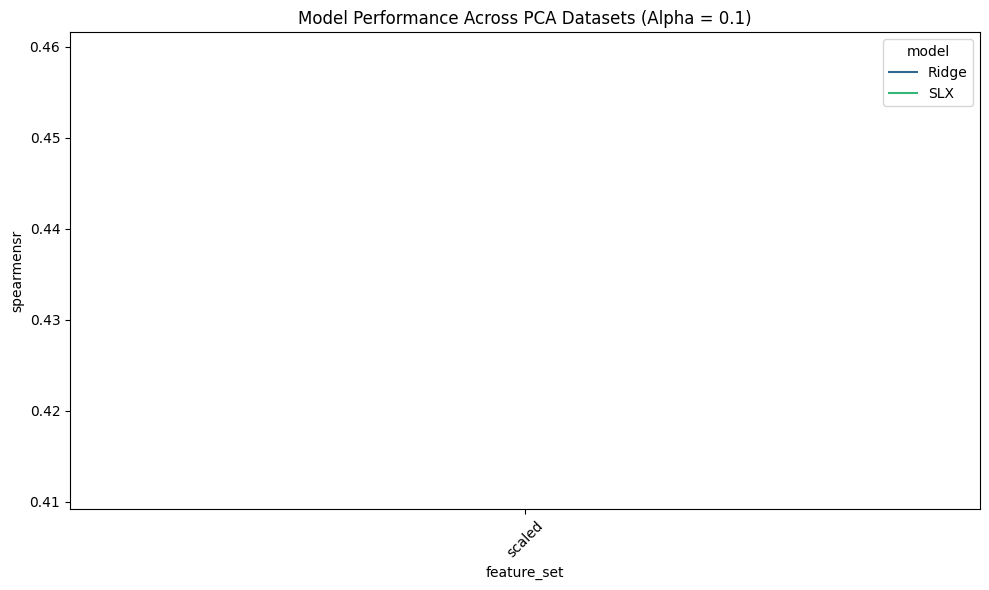

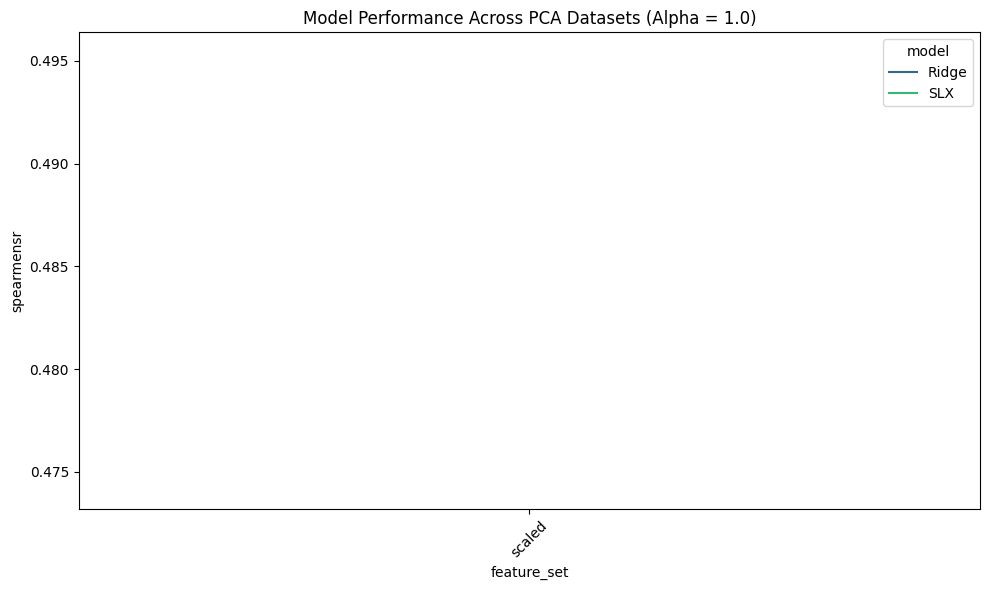

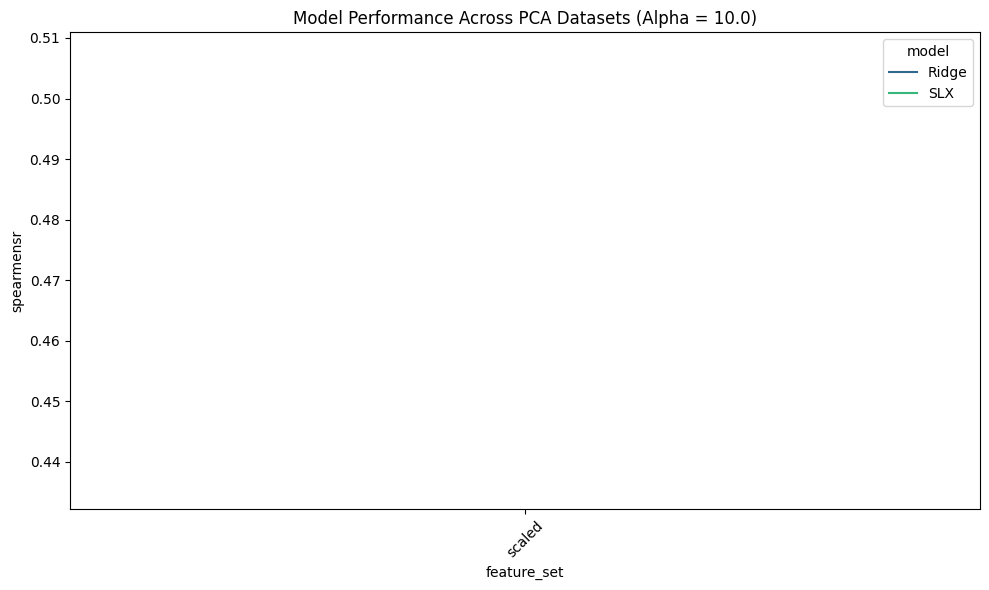

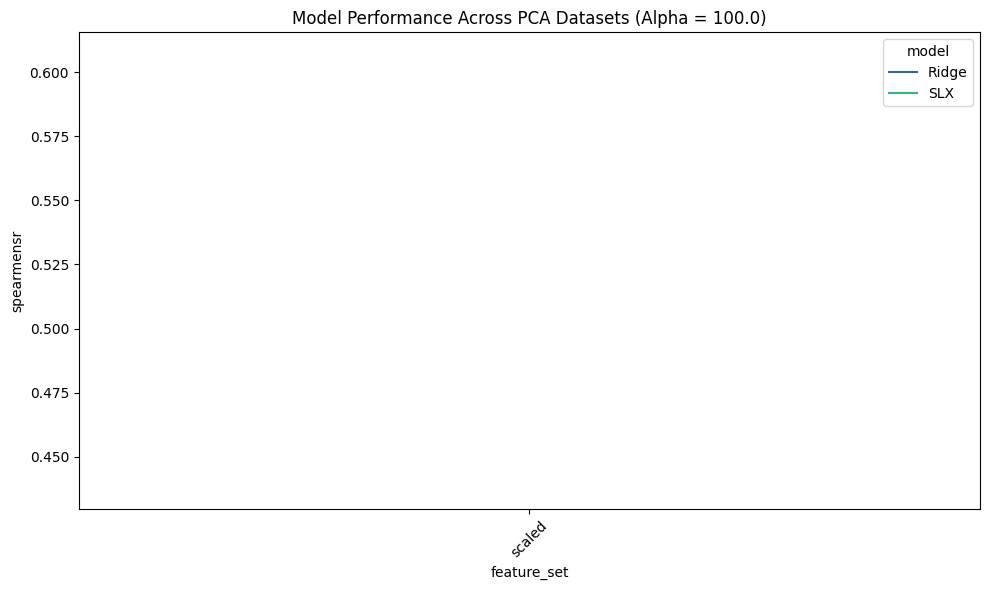

In [179]:
alpha_values = results_df['alpha'].unique()

for alpha_val in alpha_values:
    plt.figure(figsize=(10, 6))
    
    sns.lineplot(
        data=results_df[results_df['alpha'] == alpha_val],
        x='feature_set',
        y='spearmensr',
        hue='model',
        markers='o',
        errorbar=None,       # removes shaded CI
        palette="viridis"
    )
    
    plt.xticks(rotation=45)
    plt.title(f'Model Performance Across PCA Datasets (Alpha = {alpha_val})')
    plt.tight_layout()
    
    plt.show()

#### CV R Squared Scores

##### Mean

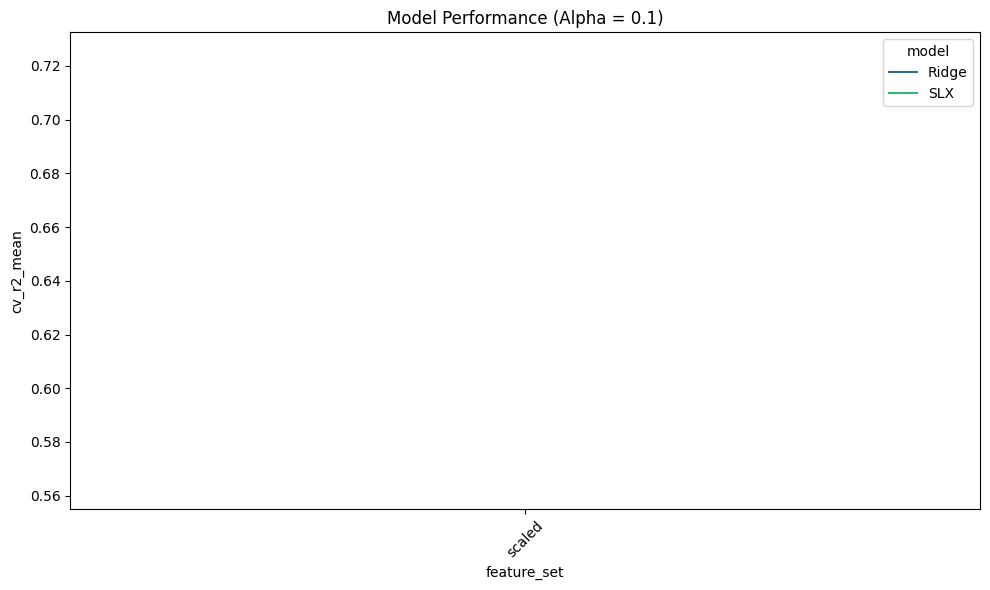

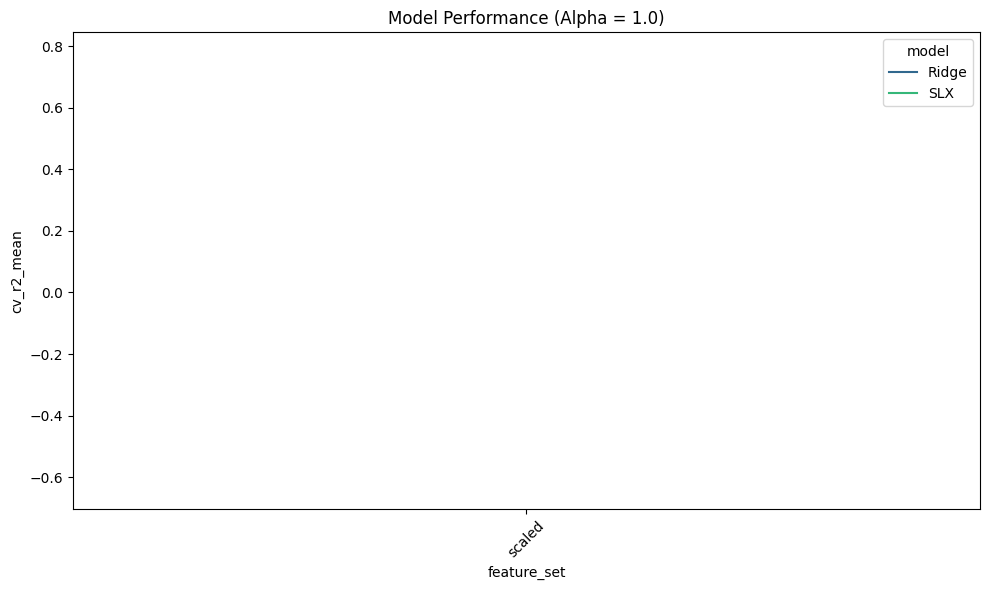

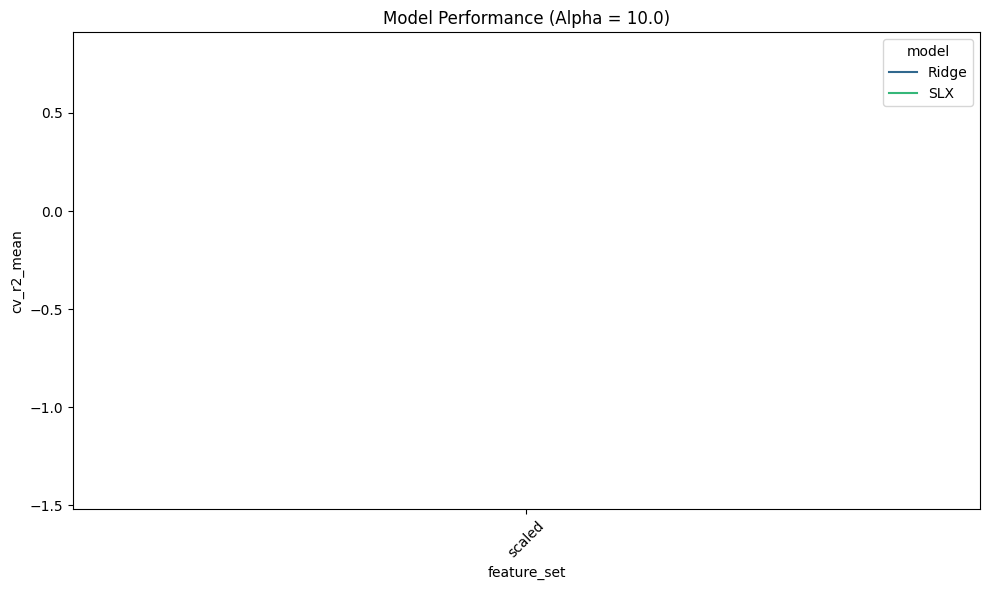

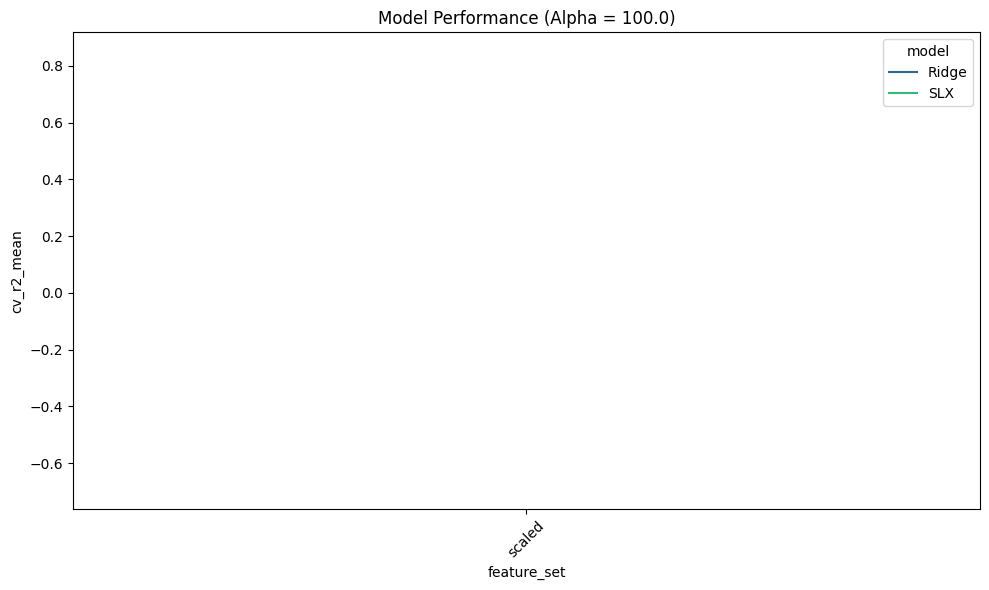

In [180]:
alpha_values = results_df['alpha'].unique()

for alpha_val in alpha_values:
    plt.figure(figsize=(10, 6))
    
    sns.lineplot(
        data=results_df[results_df['alpha'] == alpha_val],
        x='feature_set',
        y='cv_r2_mean',
        hue='model',
        markers='o',
        errorbar=None,       # removes shaded CI
        palette="viridis"
    )
    
    plt.xticks(rotation=45)
    plt.title(f'Model Performance (Alpha = {alpha_val})')
    plt.tight_layout()
    
    plt.show()

##### Spread

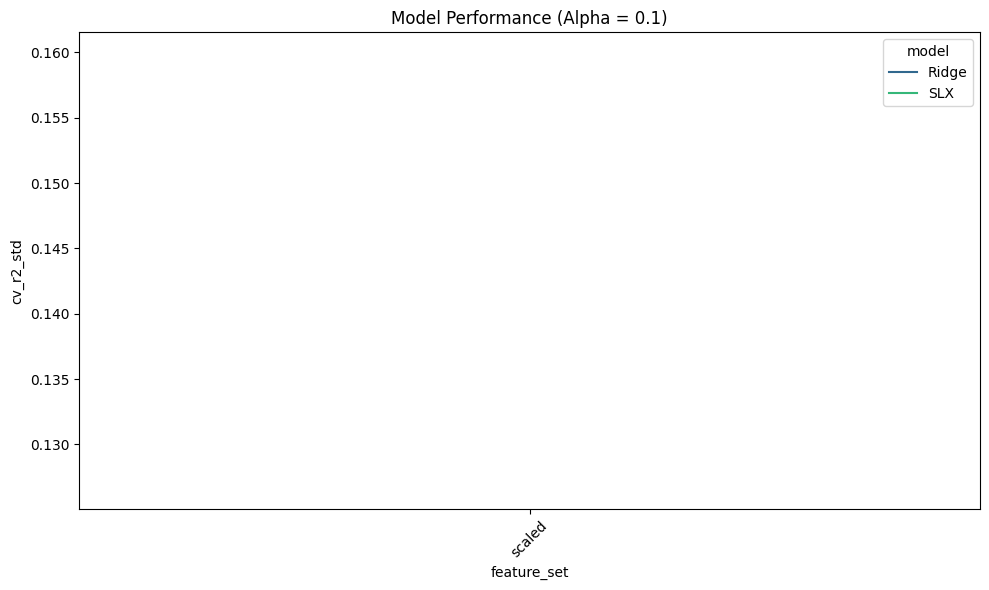

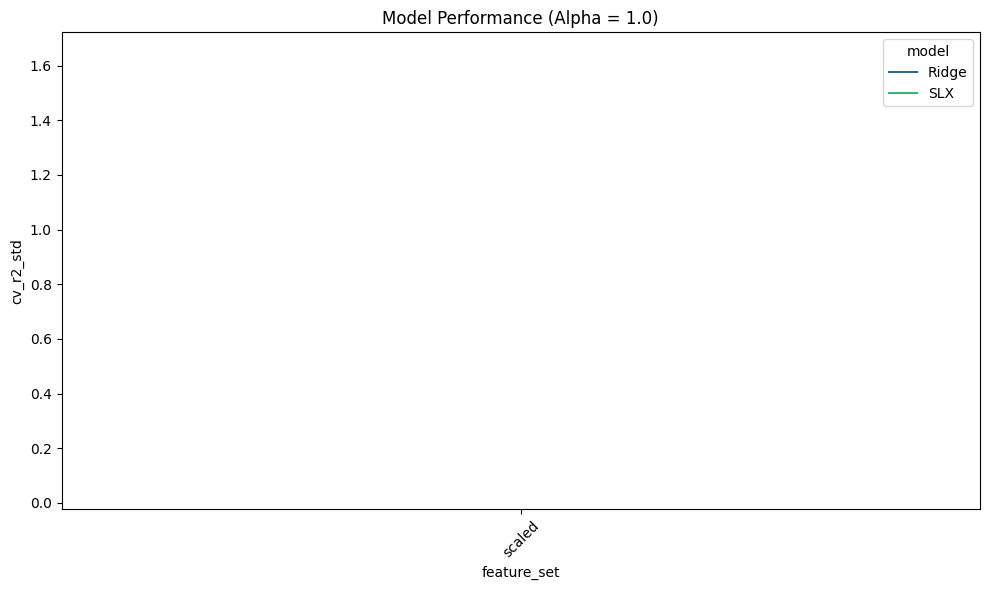

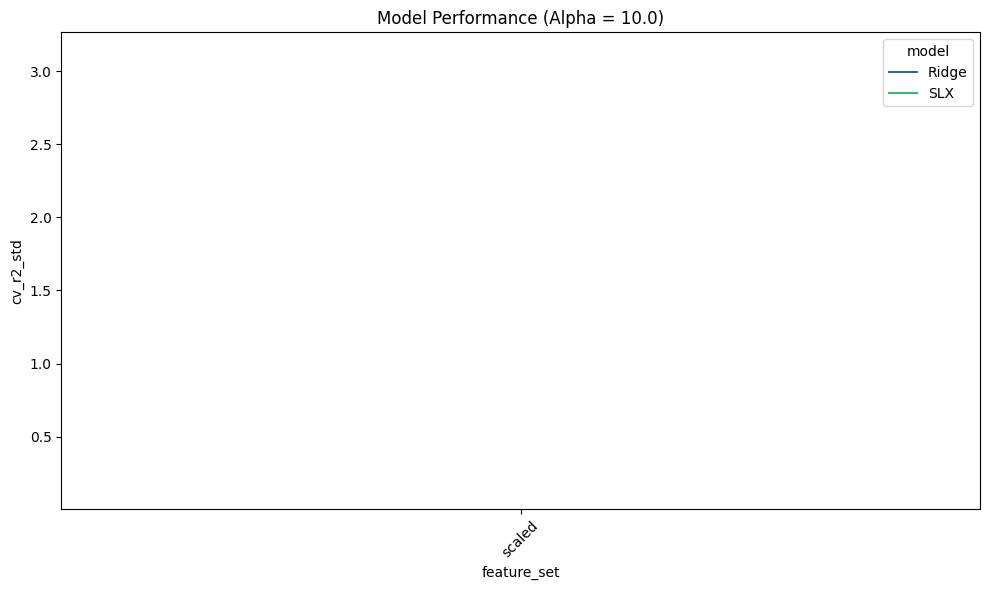

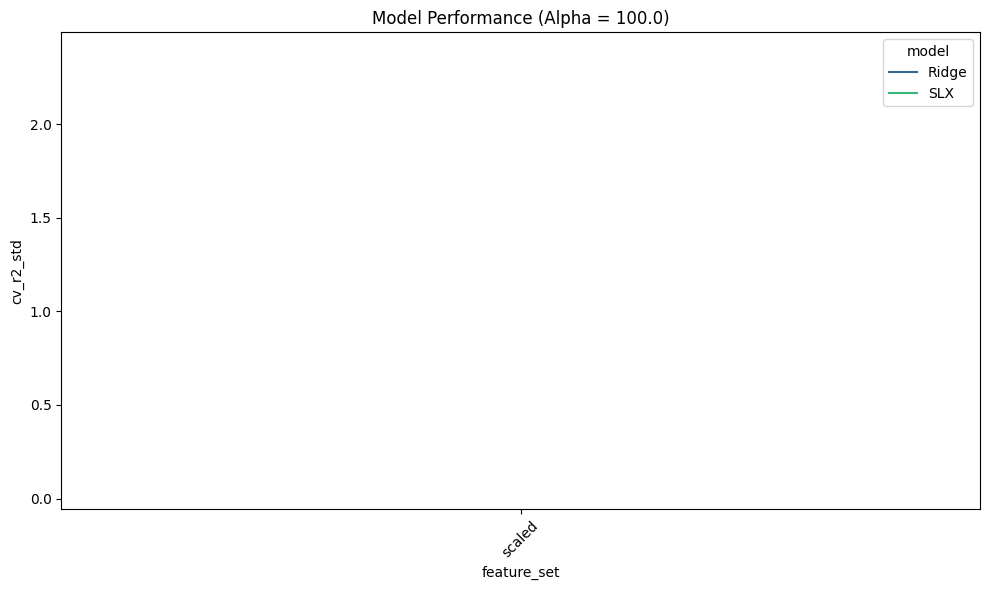

In [181]:
alpha_values = results_df['alpha'].unique()

for alpha_val in alpha_values:
    plt.figure(figsize=(10, 6))
    
    sns.lineplot(
        data=results_df[results_df['alpha'] == alpha_val],
        x='feature_set',
        y='cv_r2_std',
        hue='model',
        markers='o',
        errorbar=None,       # removes shaded CI
        palette="viridis"
    )
    
    plt.xticks(rotation=45)
    plt.title(f'Model Performance (Alpha = {alpha_val})')
    plt.tight_layout()
    
    plt.show()

#### Coeff Analysis

In [182]:
coefs_df.head()

,validation_value,cv_mean,cv_spread,model,alpha,feature_set,direction
feature_name,,,,,,,
X0,-3.822203,-2.599999,2.321249,Ridge,0.01,scaled,2019 -> 2025
X1,-4.146474,-2.447972,1.370227,Ridge,0.01,scaled,2019 -> 2025
X2,-0.978497,-0.684714,1.508363,Ridge,0.01,scaled,2019 -> 2025
X3,0.000000,0.000000,0.000000,Ridge,0.01,scaled,2019 -> 2025
X4,-3.581961,-1.919846,1.627475,Ridge,0.01,scaled,2019 -> 2025


In [183]:
# Get top 3 configs by spearmensr
top3_configs = results_df.sort_values(by='spearmensr', ascending=False).head(1)

# Merge with coefs_df to get coefficients for these top 3
top3_coefs = coefs_df.reset_index().merge(
    top3_configs[['model', 'alpha', 'feature_set', 'direction']],
    on=['model', 'alpha', 'feature_set', 'direction'],
    how='inner'
)

# Optional: set feature_name as index again
top3_coefs.set_index('feature_name', inplace=True)

top3_coefs.sort_values(by='validation_value')

,validation_value,cv_mean,cv_spread,model,alpha,feature_set,direction
feature_name,,,,,,,
X194,-1.464338,-1.089545,0.561059,Ridge,100.0,scaled,2019 -> 2025
X194,-1.464338,-1.089545,0.561059,Ridge,100.0,scaled,2019 -> 2025
X194,-1.464338,-1.089545,0.561059,Ridge,100.0,scaled,2019 -> 2025
X305,-1.407558,-1.271779,0.076870,Ridge,100.0,scaled,2019 -> 2025
X305,-1.407558,-1.271779,0.076870,Ridge,100.0,scaled,2019 -> 2025
...,...,...,...,...,...,...,...
X61,2.026055,1.869832,0.029196,Ridge,100.0,scaled,2019 -> 2025
X61,2.026055,1.869832,0.029196,Ridge,100.0,scaled,2019 -> 2025
X34,2.026055,1.869832,0.029196,Ridge,100.0,scaled,2019 -> 2025


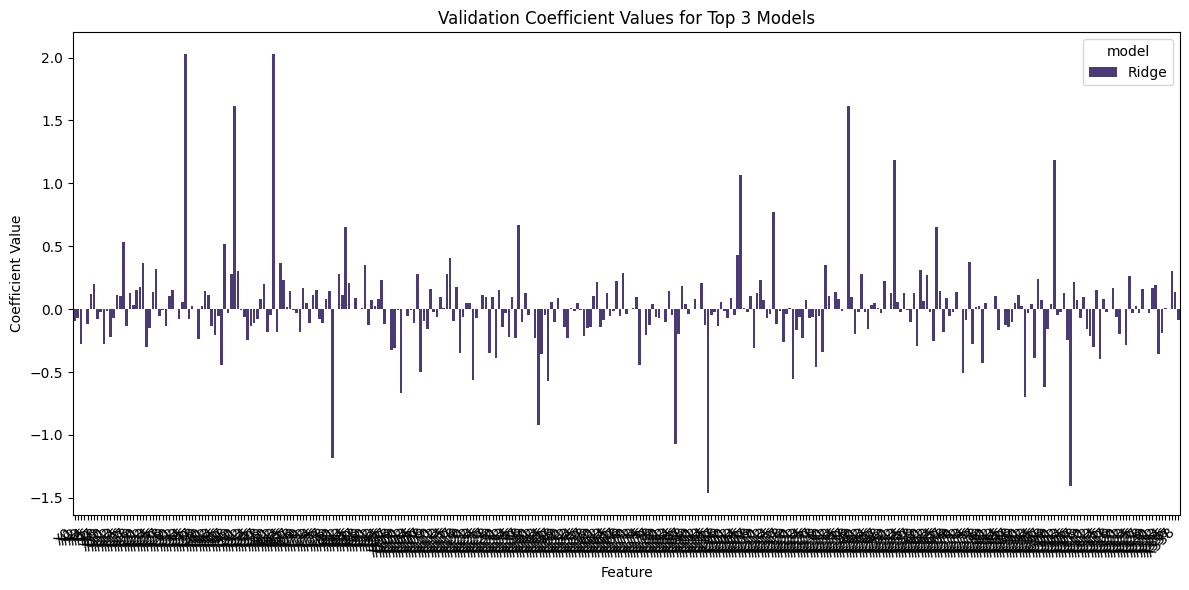

In [184]:
import matplotlib.pyplot as plt
import seaborn as sns

# Example: plot top 3 configurations
df_plot = top3_coefs.reset_index()  # ensure feature_name is a column

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_plot,
    x='feature_name',
    y='validation_value',
    hue='model'
)

plt.xticks(rotation=45, ha='right')
plt.title('Validation Coefficient Values for Top 3 Models')
plt.ylabel('Coefficient Value')
plt.xlabel('Feature')
plt.tight_layout()
plt.show()

## Regularisation with Lasso and Elastic Net

In [203]:
new_results_df, _ = evaluate_models(models=['Lasso', 'ElasticNet'])

c:\Users\danie\.venvs\ds\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.547e+00, tolerance: 5.684e+00
  model = cd_fast.enet_coordinate_descent(
c:\Users\danie\.venvs\ds\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.079e+01, tolerance: 5.944e+00
  model = cd_fast.enet_coordinate_descent(
c:\Users\danie\.venvs\ds\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.267e+01, toleranc

In [204]:
new_results_df.sort_values(by='spearmensr', ascending=False).head(10)


,feature_set,model,cv_rmse_std,cv_rmse_mean,cv_r2_std,cv_r2_mean,cv_spearmensr_std,cv_spearmensr_mean,val_r2,spearmensr,alpha,direction
2,scaled,Lasso,1.553664,6.249631,0.065397,0.846928,0.014256,0.943484,0.702798,0.959519,1.00,2019 -> 2025
1,scaled,Lasso,1.868125,5.977624,0.094495,0.853117,0.009237,0.940158,0.590934,0.949866,0.10,2019 -> 2025
3,scaled,Lasso,1.724342,12.100391,0.052453,0.444760,0.016352,0.929245,0.420527,0.946403,10.00,2019 -> 2025
12,scaled,Lasso,0.280093,5.182709,0.033535,0.887489,0.015917,0.949202,0.768385,0.941193,1.00,2025 -> 2019
13,scaled,Lasso,1.277745,11.606879,0.039811,0.459744,0.023854,0.934229,0.392083,0.937703,10.00,2025 -> 2019
7,scaled,ElasticNet,1.116404,6.672184,0.050012,0.826858,0.013045,0.928012,-0.038200,0.920297,1.00,2019 -> 2025
6,scaled,ElasticNet,1.673965,6.248162,0.084300,0.842797,0.012494,0.931729,-0.227577,0.915908,0.10,2019 -> 2025
8,scaled,ElasticNet,1.009679,9.488422,0.063693,0.652219,0.030650,0.876484,-0.025356,0.902230,10.00,2019 -> 2025
5,scaled,ElasticNet,1.292748,7.326698,0.074755,0.788996,0.012894,0.905577,-0.586037,0.897800,0.01,2019 -> 2025
0,scaled,Lasso,1.564922,8.168330,0.085691,0.741406,0.014329,0.888556,-0.832095,0.895101,0.01,2019 -> 2025


In [208]:
# Get top 3 configs by spearmensr
top3_configs = new_results_df.sort_values(by='spearmensr', ascending=False).head(1)

# Merge with coefs_df to get coefficients for these top 3
top3_coefs = _.reset_index().merge(
    top3_configs[['model', 'alpha', 'feature_set', 'direction']],
    on=['model', 'alpha', 'feature_set', 'direction'],
    how='inner'
)

# Optional: set feature_name as index again
top3_coefs.set_index('feature_name', inplace=True)

top3_coefs.sort_values(by='validation_value', ascending=False)

,validation_value,cv_mean,cv_spread,model,alpha,feature_set,direction
feature_name,,,,,,,
X34,13.445506,13.336778,0.789600,Lasso,1.0,scaled,2019 -> 2025
X204,0.570423,0.314930,0.276612,Lasso,1.0,scaled,2019 -> 2025
X226,0.300903,0.251200,0.271588,Lasso,1.0,scaled,2019 -> 2025
X274,0.076427,0.089340,0.152516,Lasso,1.0,scaled,2019 -> 2025
X61,0.067776,0.076542,0.038893,Lasso,1.0,scaled,2019 -> 2025
...,...,...,...,...,...,...,...
X286,-0.300748,-0.208790,0.180057,Lasso,1.0,scaled,2019 -> 2025
X184,-0.589688,-0.547971,0.110826,Lasso,1.0,scaled,2019 -> 2025
X79,-0.856097,-0.870008,0.186424,Lasso,1.0,scaled,2019 -> 2025


In [212]:
original_feature_name = data_2019.columns[34]
print(original_feature_name)

total_nwr_claims
